In [13]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [14]:
run_file_split_sky = os.path.join('/data/user/fkrafft/split_sky_trials', 'improvement_summary.csv')
run_file_all_sky = os.path.join('/data/user/fkrafft/updated_king_bias', 'improvement_summary.csv')

In [15]:
split_df = pd.read_csv(run_file_split_sky, index_col= 0)
all_sky_df = pd.read_csv(run_file_all_sky, index_col = 0)
split_df.columns

Index(['run', 'sin_dec', 'disc_flux_ratio', 'sens_flux_ratio', 'ns_bias_ratio',
       'gamma_bias_ratio', 'n_bins', 'n_bins_energy', 'n_bins_dec',
       'n_bins_sigma'],
      dtype='str')

### 1. For each declination: Compare each metric

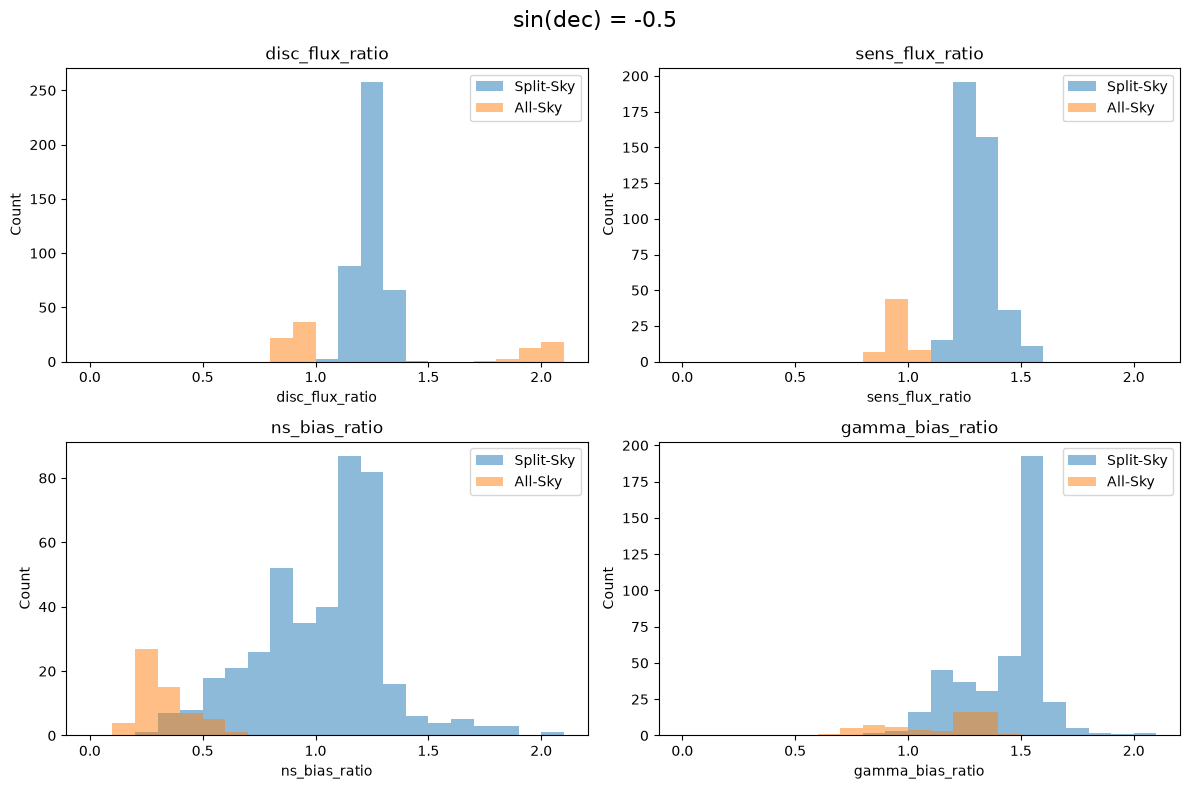

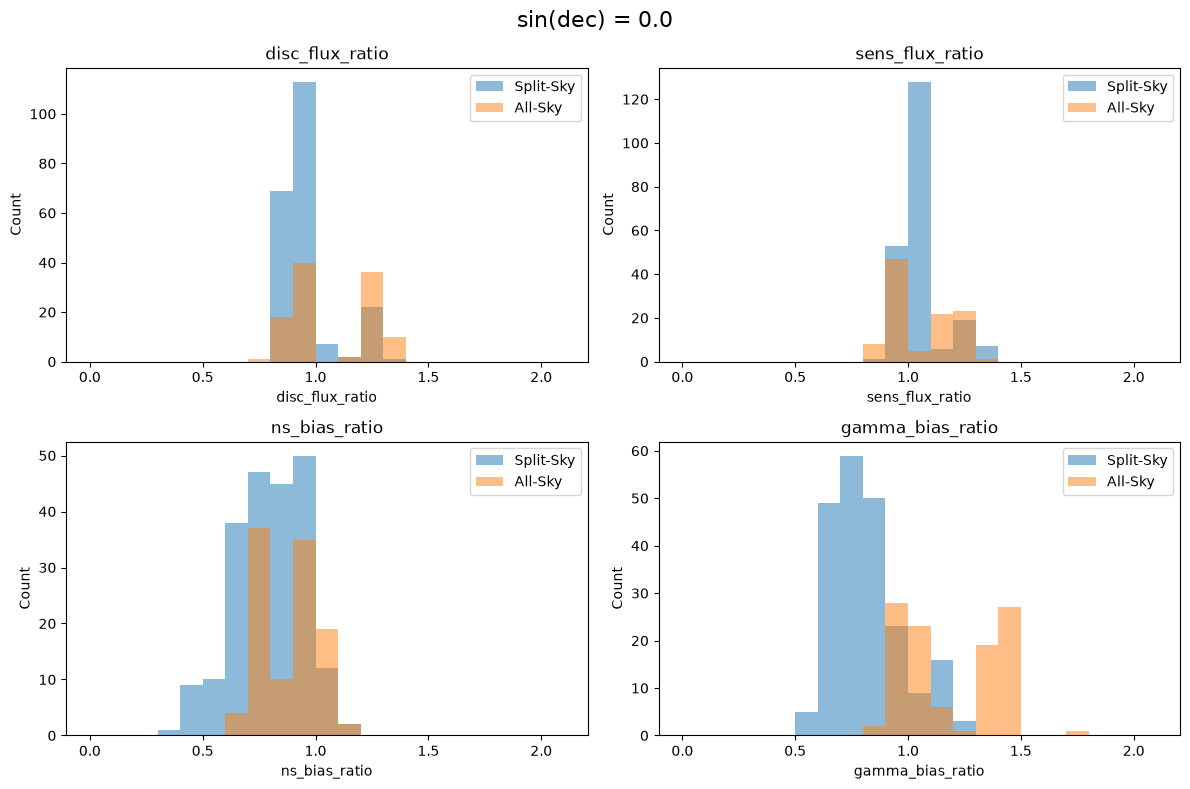

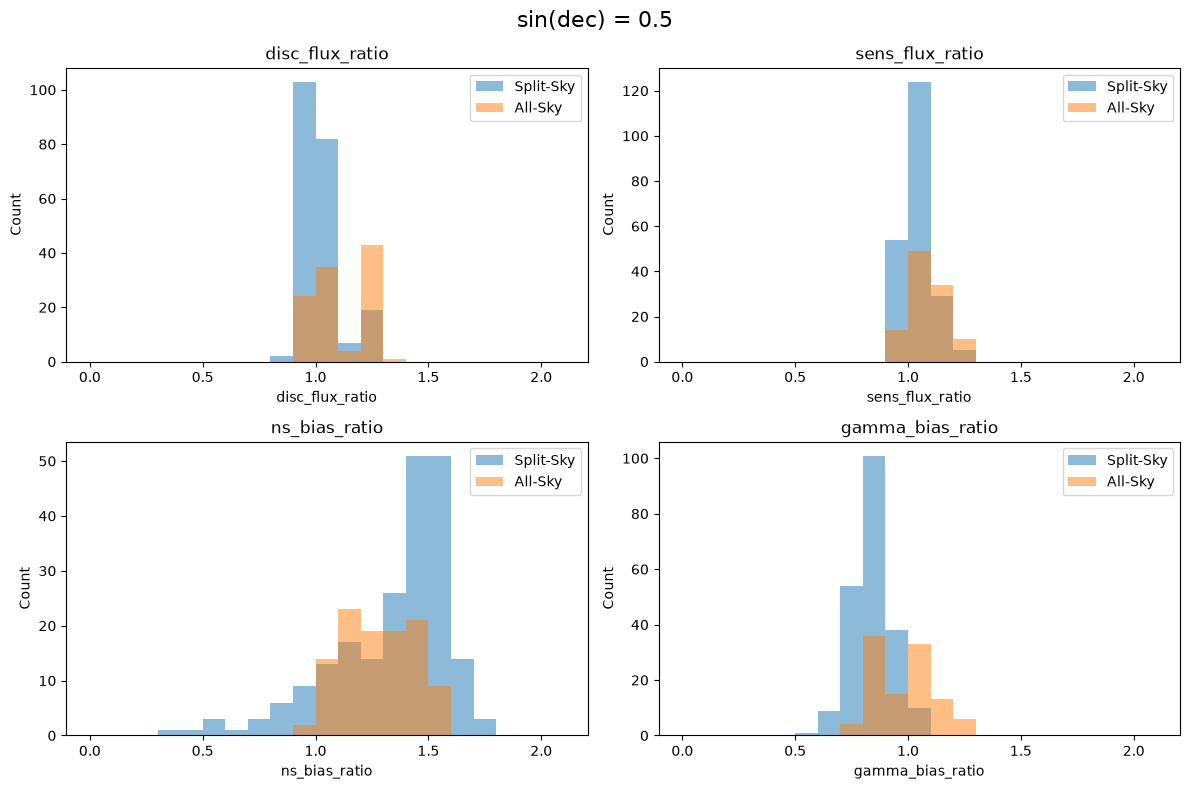

In [16]:
metrics = [
    "disc_flux_ratio",
    "sens_flux_ratio",
    "ns_bias_ratio",
    "gamma_bias_ratio",
]

sin_decs = sorted(split_df["sin_dec"].unique())

for sin_dec in sin_decs:

    # Select this sin_dec from both dataframes
    d1 = split_df[split_df["sin_dec"] == sin_dec]
    d2 = all_sky_df[all_sky_df["sin_dec"] == sin_dec]

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()

    for ax, metric in zip(axes, metrics):

        # Common bins so the two histograms are directly comparable
        values = np.concatenate([
            d1[metric].dropna().values,
            d2[metric].dropna().values
        ])

        bins = np.append(np.linspace(0, 2, 21), 2.1)

        ax.hist(
            d1[metric],
            bins=bins,
            alpha=0.5,
            label="Split-Sky"
        )

        ax.hist(
            d2[metric],
            bins=bins,
            alpha=0.5,
            label="All-Sky"
        )

        ax.set_title(metric)
        ax.set_xlabel(metric)
        ax.set_ylabel("Count")
        ax.legend()

    fig.suptitle(f"sin(dec) = {sin_dec}", fontsize=16)

    plt.tight_layout()
    plt.show()

In [17]:
def rank_runs_by_bias(df):
    """
    Rank runs by their mean ns_bias_ratio across all sin_dec values.

    Parameters
    ----------
    df : pd.DataFrame
        Must contain columns 'run' and 'ns_bias_ratio'.

    Returns
    -------
    pd.DataFrame
        Columns: rank, run, mean_ns_bias_ratio
    """
    ranking = (
        df.groupby("run", as_index=False)["ns_bias_ratio"]
        .mean()
        .rename(columns={"ns_bias_ratio": "mean_ns_bias_ratio"})
        .sort_values("mean_ns_bias_ratio")
        .reset_index(drop=True)
    )

    ranking.insert(0, "rank", range(1, len(ranking) + 1))

    return ranking

In [18]:
split_ranking_south = rank_runs_by_bias(split_df[split_df['sin_dec'] == -0.5])
split_ranking_south

,rank,run,mean_ns_bias_ratio
0,1,E5_D4_902b96_S10_MC300,0.271031
1,2,E100_D24_b2448a_S05_MC300,0.301548
2,3,E15_D199_3d5b24_S05_MC300,0.358157
3,4,E5_D9_fc2efc_S10_MC300,0.359380
4,5,E200_D14_214963_S05_MC300,0.362116
...,...,...,...
410,411,E15_D4_902b96_S05_MC300,1.776938
411,412,E5_D14_214963_S05_MC300,1.858372
412,413,E10_D4_902b96_S05_MC300,1.877283
413,414,E5_D9_fc2efc_S05_MC300,1.878289


In [19]:
split_ranking_north = rank_runs_by_bias(split_df[split_df['sin_dec'] > -0.5])
split_ranking_north 

,rank,run,mean_ns_bias_ratio
0,1,E30_D44_9e6cc1_S50_MC300,0.406114
1,2,E20_D44_9e6cc1_S50_MC300,0.478827
2,3,E30_D24_91ecd3_S50_MC300,0.499383
3,4,E20_D24_91ecd3_S50_MC300,0.532228
4,5,E15_D44_9e6cc1_S50_MC300,0.551392
...,...,...,...
209,210,E5_D4_902b96_S30_MC300,1.374968
210,211,E5_D14_fbbb47_S10_MC300,1.385234
211,212,E10_D14_fbbb47_S15_MC300,1.385701
212,213,E5_D14_fbbb47_S15_MC300,1.408751


Best southern sky binning

In [28]:
south_best = split_df[split_df['run'] == 'E5_D4_902b96_S10_MC300'][split_df['sin_dec'] == -0.5]
south_best

/tmp/ipykernel_2782297/1118092129.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  south_best = split_df[split_df['run'] == 'E5_D4_902b96_S10_MC300'][split_df['sin_dec'] == -0.5]


,run,sin_dec,disc_flux_ratio,sens_flux_ratio,ns_bias_ratio,gamma_bias_ratio,n_bins,n_bins_energy,n_bins_dec,n_bins_sigma
758,E5_D4_902b96_S10_MC300,-0.5,1.25348,1.291161,0.271031,1.077126,200,5,4,10


Best northern sky binning

In [29]:
north_best = split_df[split_df['run'] == 'E30_D44_9e6cc1_S50_MC300'][split_df['sin_dec'] > -0.5]
north_best

/tmp/ipykernel_2782297/1284841518.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  north_best = split_df[split_df['run'] == 'E30_D44_9e6cc1_S50_MC300'][split_df['sin_dec'] > -0.5]


,run,sin_dec,disc_flux_ratio,sens_flux_ratio,ns_bias_ratio,gamma_bias_ratio,n_bins,n_bins_energy,n_bins_dec,n_bins_sigma
297,E30_D44_9e6cc1_S50_MC300,0.0,1.254001,1.252167,0.448016,1.160787,66000,30,44,50
298,E30_D44_9e6cc1_S50_MC300,0.5,1.193637,1.156135,0.364213,0.815385,66000,30,44,50


combined mean for both skies:

In [31]:
best_bias_config_split_sky = pd.concat([south_best, north_best])
best_bias_config_split_sky

,run,sin_dec,disc_flux_ratio,sens_flux_ratio,ns_bias_ratio,gamma_bias_ratio,n_bins,n_bins_energy,n_bins_dec,n_bins_sigma
758,E5_D4_902b96_S10_MC300,-0.5,1.253480,1.291161,0.271031,1.077126,200,5,4,10
297,E30_D44_9e6cc1_S50_MC300,0.0,1.254001,1.252167,0.448016,1.160787,66000,30,44,50
298,E30_D44_9e6cc1_S50_MC300,0.5,1.193637,1.156135,0.364213,0.815385,66000,30,44,50


In [33]:
best_split_sky_mean_bias = np.mean(best_bias_config_split_sky['ns_bias_ratio'])
best_split_sky_mean_bias

np.float64(0.36108632789567624)

In [24]:
all_sky_ranking = rank_runs_by_bias(all_sky_df)
all_sky_ranking

,rank,run,mean_ns_bias_ratio
0,1,E25_86544b_D14_f505b9_S15_MC300,0.821230
1,2,E8_a408dd_D49_76f754_S15_MC300,0.824542
2,3,E8_a408dd_D14_f505b9_S15_MC300,0.833950
3,4,E8_b26d8e_D49_76f754_S20_MC300,0.837896
4,5,E8_b26d8e_D14_f505b9_S15_MC300,0.842242
...,...,...,...
102,103,E25_86544b_D24_f8ce7a_S100_MC300,3.450686
103,104,E8_b26d8e_D49_76f754_S100_MC300,3.476608
104,105,E13_e0c494_D49_76f754_S100_MC300,3.502959
105,106,E25_86544b_D49_76f754_S50_MC300,3.531778


In [35]:
best_bias_config_all_sky = all_sky_df[all_sky_df['run'] == 'E25_86544b_D14_f505b9_S15_MC300']
best_bias_config_all_sky

,run,sin_dec,disc_flux_ratio,sens_flux_ratio,ns_bias_ratio,gamma_bias_ratio,n_bins,n_bins_energy,n_bins_dec,n_bins_sigma
258,E25_86544b_D14_f505b9_S15_MC300,-0.5,0.945415,0.918270,0.195562,1.254549,5250,25,14,15
259,E25_86544b_D14_f505b9_S15_MC300,0.0,0.871707,0.915584,0.978962,1.027263,5250,25,14,15
260,E25_86544b_D14_f505b9_S15_MC300,0.5,1.010605,1.035080,1.289165,0.856410,5250,25,14,15
